# CRISPYx Tutorial

This tutorial walks through the Scanpy-style workflow provided by ``crispyx``.

## Prerequisites

Install the project in editable mode (with the optional ``test`` extras) to make the package importable and provide AnnData, NumPy, pandas, and SciPy:

```bash
pip install -e .[test]
```

## Prepare the Adamson subset dataset

This tutorial uses the included Adamson subset stored at ``data/Adamson_subset.h5ad``.


In [1]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))
DATA_PATH = ROOT / 'data' / 'Adamson_subset.h5ad'
OUTPUT_DIR = ROOT / 'notebooks' / 'tutorial_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import crispyx as cx

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Expected dataset at {DATA_PATH}')


/data/miniforge3/envs/pert/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Inspect the on-disk AnnData

``cx.read_h5ad_ondisk`` returns a read-only :class:`cx.AnnData` wrapper. The ``obs`` and ``var`` accessors expose ``head`` and ``load`` helpers so you can preview metadata without materialising the entire object.

In [2]:
adata_ro = cx.read_h5ad_ondisk(DATA_PATH)
adata_ro

AnnData object with n_obs × n_vars = 1716 × 11630 backed at '/home/jinhongd/Streamlining-CRISPR-Screen-Analysis/data/Adamson_subset.h5ad'
    obs: 'perturbation', 'n_genes', 'dataset', 'celltype'
    var: 'Ensembl_ID'
    uns: 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
First obs rows:
                 perturbation  n_genes  dataset celltype
Cell_barcodes                                           
AAACATACAAGATG-1      control     2914  Adamson     K562
AAACATTGCATTGG-1      control     3999  Adamson     K562
AAACGGCTAATGCC-1       AMIGO3     3947  Adamson     K562
AAAGACGAACTCAG-1      control     2713  Adamson     K562
AAAGAGACTCGCCT-1      control     3678  Adamson     K562
First var rows:
                  Ensembl_ID
Gene_symbol                 
LINC00115    ENSG00000225880
NOC2L        ENSG00000188976
KLHL17       ENSG00000187961
HES4         ENSG00000188290
ISG15        ENSG00000187608


AnnData(path=/home/jinhongd/Streamlining-CRISPR-Screen-Analysis/data/Adamson_subset.h5ad, mode='r')

In [3]:
adata_ro.obs.head()

,perturbation,n_genes,dataset,celltype
Cell_barcodes,,,,
AAACATACAAGATG-1,control,2914,Adamson,K562
AAACATTGCATTGG-1,control,3999,Adamson,K562
AAACGGCTAATGCC-1,AMIGO3,3947,Adamson,K562
AAAGACGAACTCAG-1,control,2713,Adamson,K562
AAAGAGACTCGCCT-1,control,3678,Adamson,K562


In [4]:
adata_ro.var.head()

,Ensembl_ID
Gene_symbol,
LINC00115,ENSG00000225880
NOC2L,ENSG00000188976
KLHL17,ENSG00000187961
HES4,ENSG00000188290
ISG15,ENSG00000187608


## Quality control with ``cx.pp``

The preprocessing namespace mirrors Scanpy's API. Each function returns a new ``cx.AnnData`` object backed by an ``.h5ad`` file.

In [5]:
qc_result = cx.quality_control_summary(
    adata_ro,
    perturbation_column='perturbation',
    min_genes=5,
    min_cells_per_perturbation=5,
    output_dir=OUTPUT_DIR,
    data_name='tutorial',
)
qc_preview = pd.DataFrame(
    {
        'perturbation': adata_ro.obs['perturbation'],
        'qc_pass': qc_result.cell_mask,
    }
)
adata_ro = qc_result.filtered
print(f"QC result: {qc_result.cell_mask.sum()} / {len(qc_result.cell_mask)} cells passed")
qc_preview.head(5)

QC result: 1716 / 1716 cells passed


,perturbation,qc_pass
Cell_barcodes,,
AAACATACAAGATG-1,control,True
AAACATTGCATTGG-1,control,True
AAACGGCTAATGCC-1,AMIGO3,True
AAAGACGAACTCAG-1,control,True
AAAGAGACTCGCCT-1,control,True


## Streaming Preprocessing with `cx.pp.normalize_total_log1p`

For large datasets that would OOM during normalization, use the streaming preprocessing function. This is the equivalent of `scanpy.pp.normalize_total()` + `scanpy.pp.log1p()` but processes data in chunks.

In [6]:
# Create a normalized + log1p version of the QC-filtered data (streaming)
# This works on huge datasets without loading into memory
adata_norm = cx.pp.normalize_total_log1p(
    adata_ro,  # Pass the AnnData object directly (same as other cx.pp functions)
    output_dir=OUTPUT_DIR,
    data_name='tutorial',
    target_sum=1e4,  # Same as scanpy default
    verbose=True,
)

# Verify the output - adata_norm is a read-only AnnData wrapper
print(f"Shape: {adata_norm.shape}")
print(f"First 3 cells, first 3 genes:\n{adata_norm.to_memory().X[:3, :3].toarray()}")

Generating preprocessed dataset (streaming, normalize+log1p): /home/jinhongd/Streamlining-CRISPR-Screen-Analysis/notebooks/tutorial_outputs/crispyx_tutorial_normalized_log1p.h5ad
  ✓ Preprocessed dataset written: 1716 cells × 9238 genes
Shape: (1716, 9238)
First 3 cells, first 3 genes:
[[0.75838053 0.         0.        ]
 [0.49522132 0.         0.        ]
 [1.4766263  0.         0.5161892 ]]


## Dimension Reduction with `cx.pp.pca` and `cx.pp.neighbors`

CRISPYx provides streaming PCA and KNN graph construction that works on backed (on-disk) AnnData objects. This is essential for large CRISPR screen datasets that don't fit in memory.

- **Streaming PCA**: Automatically selects the optimal method based on gene count:
  - `sparse_cov`: Fast (~5× faster) for datasets with ≤15K genes
  - `incremental`: Memory-efficient for datasets with >15K genes
- **KNN neighbors**: Builds k-nearest neighbor graph from PCA embeddings for downstream clustering/UMAP

Results are written directly to the h5ad file using a close-write-reopen pattern, keeping `.X` on disk while adding PCA embeddings, loadings, and neighbor graphs.

In [7]:
# Streaming PCA on the normalized data
# Results are written directly to the h5ad file (close-write-reopen pattern)
cx.pp.pca(adata_norm, n_comps=20, show_progress=True)

# Check PCA results (data is read from the h5ad file)
print(f"PCA embeddings shape: {adata_norm.obsm['X_pca'].shape}")
print(f"Variance explained: {adata_norm.uns['pca']['variance_ratio'][:5]}")  # First 5 components

# Build KNN graph from PCA embeddings (also writes to h5ad)
cx.pp.neighbors(adata_norm, n_neighbors=10, method='sklearn', show_progress=True)

print(f"KNN distances shape: {adata_norm.obsp['distances'].shape}")
print(f"Number of connections: {adata_norm.obsp['connectivities'].nnz}")

Transforming data: 100%|██████████| 1/1 [00:00<00:00,  2.37it/s]


PCA embeddings shape: (1716, 20)
Variance explained: [0.02978332 0.01700597 0.01289528 0.01072036 0.00821617]
KNN distances shape: (1716, 1716)
Number of connections: 25228


### PCA Visualization

The `cx.pl` namespace provides Scanpy-style plotting wrappers:
- `cx.pl.pca()`: Scatter plot of PCA embeddings
- `cx.pl.pca_variance_ratio()`: Explained variance per component
- `cx.pl.pca_loadings()`: Gene loadings for top components

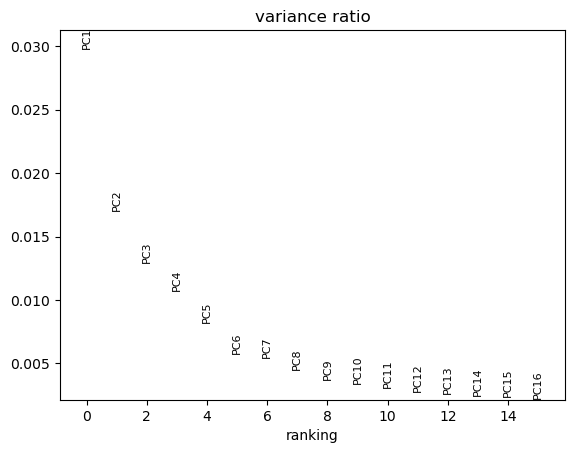

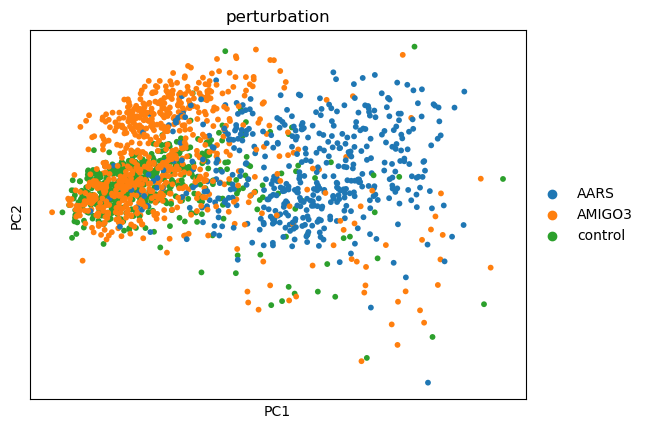

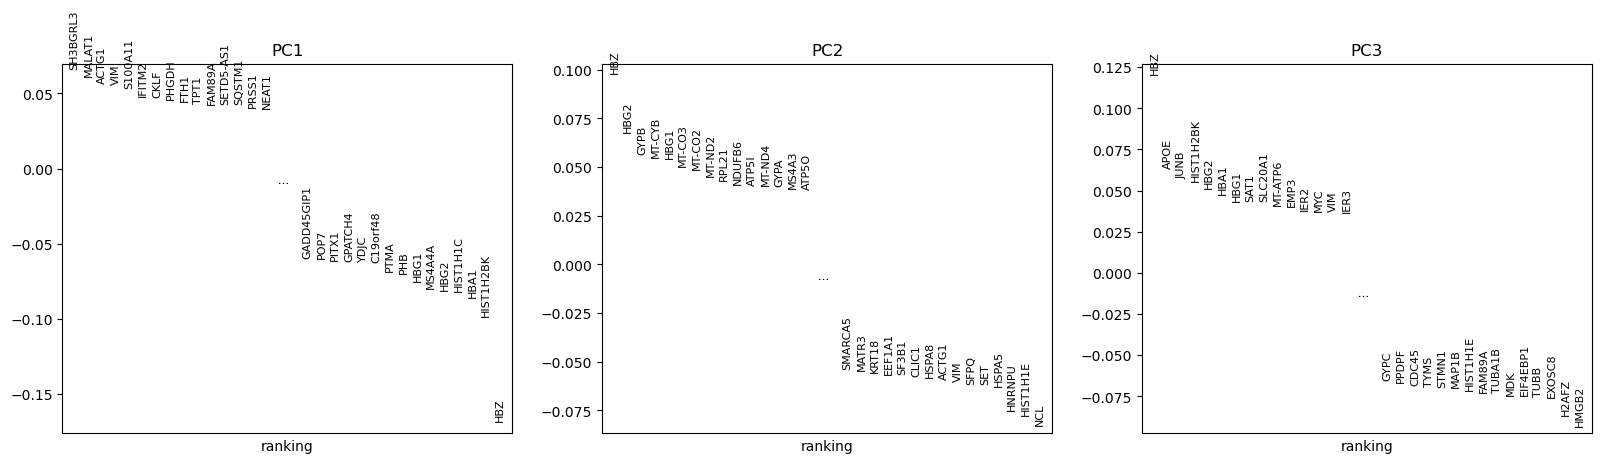

In [8]:
# Plot PCA variance explained
cx.pl.pca_variance_ratio(adata_norm, n_pcs=15)

# Plot PCA scatter colored by perturbation
cx.pl.pca(adata_norm, color='perturbation', components='1,2')

# Plot gene loadings for first 3 components
cx.pl.pca_loadings(adata_norm, components=[1, 2, 3])

### UMAP Visualization

After computing PCA and building the neighbor graph, we can compute UMAP embeddings for visualization. `cx.tl.umap()` uses the pre-computed neighbor graph from `cx.pp.neighbors()`, so it only loads the neighbor matrix (not the full expression matrix) into memory.

This is memory-efficient: approximately 0.75 MB per 1000 cells for 15 neighbors.

In [ ]:
# Compute UMAP from neighbor graph (memory-efficient)
cx.tl.umap(adata_norm, min_dist=0.5, spread=1.0)

# Check UMAP results
print(f"UMAP embedding shape: {adata_norm.obsm['X_umap'].shape}")

# Plot UMAP colored by perturbation
cx.pl.umap(adata_norm, color='perturbation')

## Pseudobulk aggregation with ``cx.pb``

Aggregate cells per perturbation on disk. The returned object can be inspected lazily, similar to the original dataset.

In [9]:
adata_pb_ro = cx.pb.average_log_expression(
    adata_ro,
    perturbation_column='perturbation',
    output_dir=OUTPUT_DIR,
    data_name='tutorial',
)
print(f"Pseudobulk shape: {adata_pb_ro.shape}")
adata_pb_ro.var.head(5)

Pseudobulk shape: (2, 9238)


""
Gene_symbol
NOC2L
KLHL17
HES4
ISG15
AGRN


## Differential expression with ``cx.tl``

Run a Wilcoxon test that mirrors ``scanpy.tl.rank_genes_groups``. ``cx.AnnData.uns`` entries also provide ``preview`` and ``load`` helpers.

In [10]:
adata_ro = cx.tl.rank_genes_groups(
    adata_ro,
    perturbation_column='perturbation',
    method='wilcoxon',
    output_dir=OUTPUT_DIR,
    data_name='tutorial',
)

# Preview a tidy DE table using plotting helper (no scanpy_format needed)
group = adata_ro.obs.load()['perturbation'].astype(str).unique()[0]
cx.pl.rank_genes_groups_df(adata_ro, group=group, n_genes=10).head()


Detected count-like floating point values in wilcoxon_test; input should be normalized/log-transformed. Please ensure preprocessing is applied upstream for consistent results.


,names,scores,logfoldchanges,pvals,pvals_adj,pts,pts_rest,group
0,MT-CYB,9.050001,34.522731,1.429672e-19,1.059797e-15,0.998667,0.998,AMIGO3
1,MT-CO2,8.998203,39.702968,2.294429e-19,1.059797e-15,0.998667,0.998,AMIGO3
2,PSMA4,8.929093,3.334039,4.295165e-19,1.322625e-15,0.985333,0.976,AMIGO3
3,HIST1H1E,-8.892310,-2.682190,5.985163e-19,1.382273e-15,0.512000,0.738,AMIGO3
4,EEF1A1,-8.673291,-1.898174,4.198071e-18,7.756356e-15,0.877333,0.976,AMIGO3


Use ``load`` to materialise the complete differential expression tables for downstream analysis.

In [11]:
group = adata_ro.obs.load()['perturbation'].astype(str).unique()[0]
top_df = cx.pl.rank_genes_groups_df(adata_ro, group=group, n_genes=5)
print(f"Top 5 DE genes for perturbation '{group}':")
top_df[['names', 'logfoldchanges', 'pvals_adj']]


Top 5 DE genes for perturbation 'AMIGO3':


,names,logfoldchanges,pvals_adj
0,MT-CYB,34.522731,1.059797e-15
1,MT-CO2,39.702968,1.059797e-15
2,PSMA4,3.334039,1.322625e-15
3,HIST1H1E,-2.682190,1.382273e-15
4,EEF1A1,-1.898174,7.756356e-15


The ``cx.AnnData`` handles close themselves when their Python objects go out of scope, so no explicit cleanup is required.

## NB-GLM Differential Expression

For more sophisticated differential expression analysis, CRISPYx provides a negative binomial GLM method that models count data directly. This is especially useful when you need to incorporate covariates or want more accurate statistical modeling.

Note: NB-GLM operates on **raw counts** (not log-normalized data), so we use the QC-filtered dataset directly.

In [12]:
# Run NB-GLM test on raw counts
# First, reload the QC-filtered dataset (not log-normalized)
qc_path = OUTPUT_DIR / 'crispyx_tutorial_filtered.h5ad'
adata_qc = cx.read_h5ad_ondisk(qc_path)

adata_nb = cx.tl.rank_genes_groups(
    adata_qc,
    perturbation_column='perturbation',
    method='nb_glm',
    output_dir=OUTPUT_DIR,
    data_name='tutorial_nb',
)
group = adata_nb.obs.load()['perturbation'].astype(str).unique()[0]
cx.pl.rank_genes_groups_df(adata_nb, group=group, n_genes=5).head()


AnnData object with n_obs × n_vars = 1716 × 9238 backed at '/home/jinhongd/Streamlining-CRISPR-Screen-Analysis/notebooks/tutorial_outputs/crispyx_tutorial_filtered.h5ad'
    obs: 'perturbation', 'n_genes', 'dataset', 'celltype'
    var: 'Ensembl_ID', 'gene_symbols'
    uns: 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
First obs rows:
                 perturbation  n_genes  dataset celltype
Cell_barcodes                                           
AAACATACAAGATG-1      control     2914  Adamson     K562
AAACATTGCATTGG-1      control     3999  Adamson     K562
AAACGGCTAATGCC-1       AMIGO3     3947  Adamson     K562
AAAGACGAACTCAG-1      control     2713  Adamson     K562
AAAGAGACTCGCCT-1      control     3678  Adamson     K562
First var rows:
                  Ensembl_ID gene_symbols
Gene_symbol                              
NOC2L        ENSG00000188976        NOC2L
KLHL17       ENSG00000187961       KLHL17
HES4         ENSG00000188290     

,names,scores,logfoldchanges,pvals,pvals_adj,pts,pts_rest,group
0,MT-CO2,10.753535,0.447715,5.703282e-27,5.268692e-23,0.998667,0.998,AMIGO3
1,HIST1H1E,-10.207953,-0.838292,1.826781e-24,8.437901e-21,0.512000,0.738,AMIGO3
2,MT-CYB,10.039458,0.402310,1.022347e-23,3.148146e-20,0.998667,0.998,AMIGO3
3,HIST1H1D,-9.473744,-0.889809,2.699881e-21,5.309860e-18,0.436000,0.656,AMIGO3
4,UQCRB,9.467219,0.537892,2.873923e-21,5.309860e-18,0.952000,0.918,AMIGO3


## LFC Shrinkage with apeGLM

Apply adaptive shrinkage to log-fold changes using the apeGLM method. This shrinks noisy/uncertain LFCs toward zero while preserving large effects, following DESeq2/PyDESeq2 best practices.

The two-step workflow (NB-GLM → shrink_lfc) gives you control over when shrinkage is applied and allows you to compare shrunk vs unshrunk results.

In [13]:
# Apply LFC shrinkage to NB-GLM results
nb_result_path = adata_nb.path

shrunk = cx.tl.shrink_lfc(
    nb_result_path,
    prior_scale_mode='global',  # Use global prior across all perturbations
)

# Compare shrunk vs raw LFC for a perturbation
import anndata
shrunk_adata = anndata.read_h5ad(nb_result_path)
print("Shrunk vs Raw LFC (first 5 genes, first perturbation):")
print(f"  Shrunk LFC: {shrunk_adata.X[0, :5]}")
print(f"  Raw LFC:    {shrunk_adata.layers['logfoldchange_raw'][0, :5]}")


Shrunk vs Raw LFC (first 5 genes, first perturbation):
  Shrunk LFC: [ 0.00091058 -0.02613842  0.0247642   0.0387339  -0.07999716]
  Raw LFC:    [ 0.00091058 -0.02613842  0.0247642   0.0387339  -0.07999716]


The shrunk LFC values are typically smaller in magnitude for genes with high uncertainty, while large, well-supported effects are preserved. This improves downstream ranking and visualization.

## Plotting (Scanpy-style)

crispyx provides `cx.pl` helpers for plotting on-disk results. The examples below mirror
Scanpy style while keeping the expression matrix on disk.


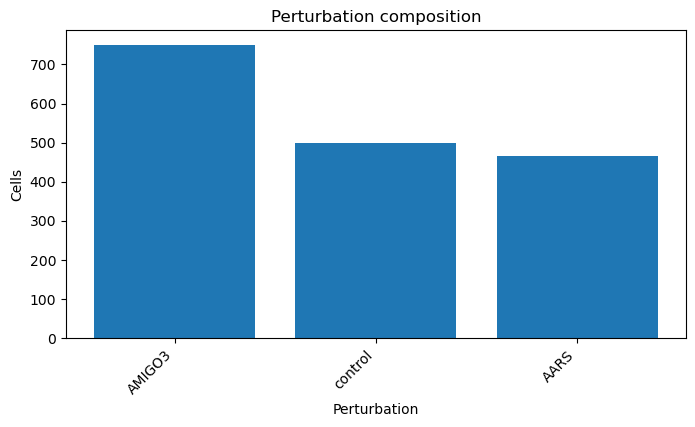

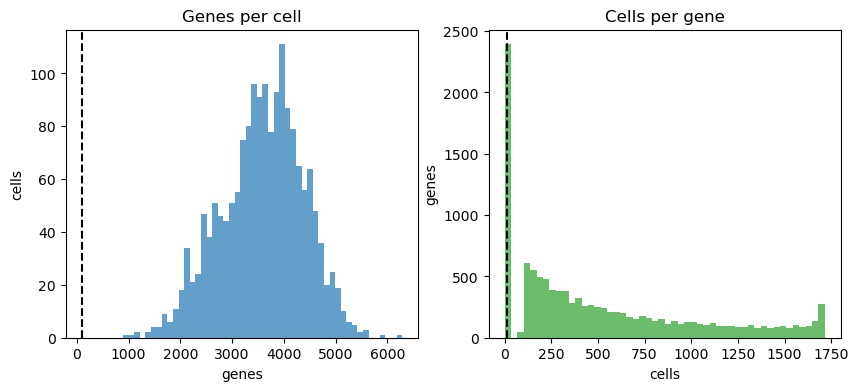

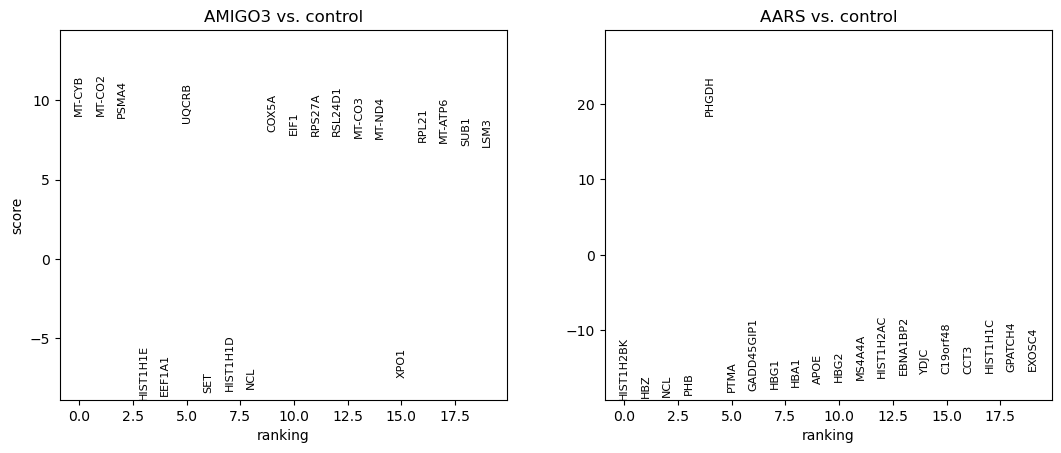

<Axes: title={'center': 'MA plot: AMIGO3 vs control'}, xlabel='log1p(mean expression)', ylabel='log2FC'>

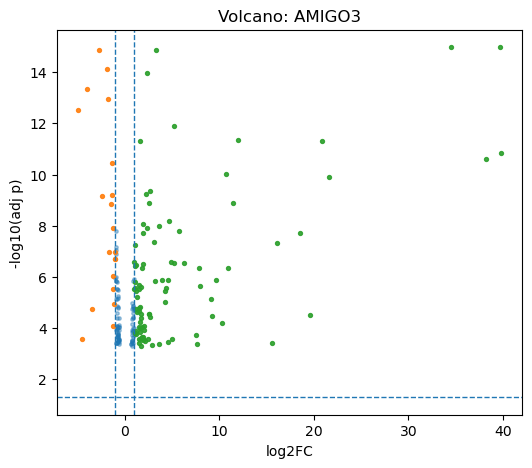

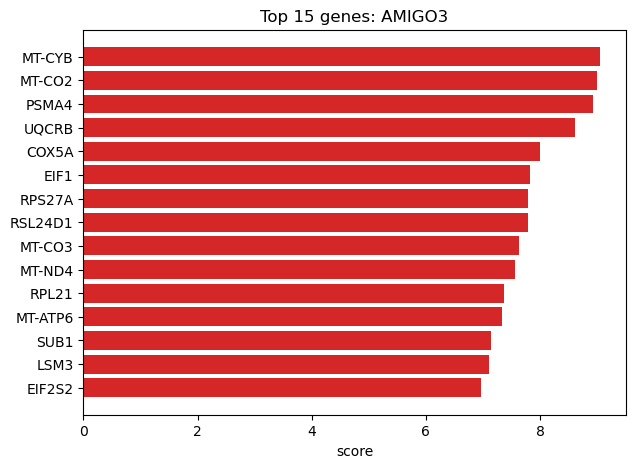

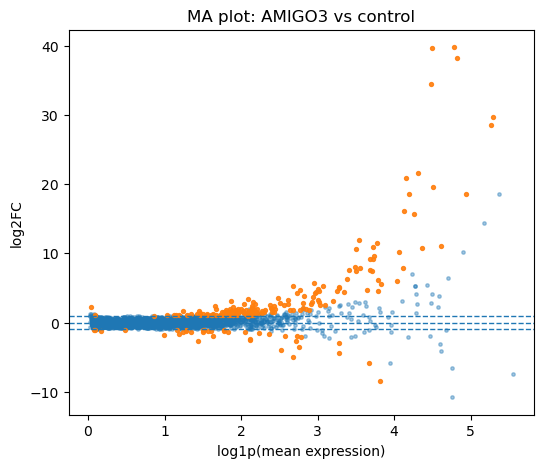

In [14]:
# QC plots
cx.pl.qc_perturbation_counts(
    data=adata_qc,
    perturbation_column='perturbation',
    cell_mask=qc_result.cell_mask,
)
cx.pl.qc_summary(qc_result, min_genes=100, min_cells_per_gene=10)

# Rank genes groups plot
cx.pl.rank_genes_groups(adata_ro, n_genes=20, sharey=False)

# Volcano / top genes
plot_group = adata_ro.obs.load()['perturbation'].astype(str).unique()[0]
df = cx.pl.rank_genes_groups_df(adata_ro, group=plot_group, n_genes=200)
cx.pl.volcano(de_df=df, group=plot_group)
cx.pl.top_genes_bar(de_df=df, group=plot_group, topn=15)

# MA plot (raw counts from QC-filtered data)
try:
    control_label = adata_ro.uns['control_label'].load()
except KeyError:
    control_label = 'control'
cx.pl.ma(
    data=adata_qc,
    de_result=adata_ro,
    group=plot_group,
    reference=control_label,
    perturbation_column='perturbation',
    mean_mode='raw',
)
